# Modelling Cancellation 
## Using ML models: Logistic Regression, XG Boost, Random Forest

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load data

In [27]:
hotel_bookings = pd.read_csv('/Users/kiepeeh1/Documents/00 Working Projects/Hotel Data Analytics/Hotel Analytics/Data/Processed_Data/final_hotel_bookings.csv')

In [28]:
hotel_bookings.head(10)

,hotel,arrival_date,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,booking_changes_flag,total_nights,revenue,total_adr,booking_time_flag,weekend_ratio,expected_loss,booking_value,booking_urgency,sameDay_booking
0,Resort Hotel,2015-07-01,0,342,2015,July,27,1,0,0,...,True,0,0.0,0.0,90+,0.0,0.0,Low Value,0.00,0
1,Resort Hotel,2015-07-01,0,737,2015,July,27,1,0,0,...,True,0,0.0,0.0,90+,0.0,0.0,Low Value,0.00,0
2,Resort Hotel,2015-07-01,0,7,2015,July,27,1,0,1,...,False,1,75.0,75.0,0-7,0.0,0.0,Low Value,0.12,0
3,Resort Hotel,2015-07-01,0,13,2015,July,27,1,0,1,...,False,1,75.0,75.0,8-30,0.0,0.0,Low Value,0.07,0
4,Resort Hotel,2015-07-01,0,14,2015,July,27,1,0,2,...,False,2,196.0,196.0,8-30,0.0,0.0,Moderate Value,0.07,0
5,Resort Hotel,2015-07-01,0,0,2015,July,27,1,0,2,...,False,2,214.0,214.0,0-7,0.0,0.0,Moderate Value,1.00,1
6,Resort Hotel,2015-07-01,0,9,2015,July,27,1,0,2,...,False,2,206.0,206.0,8-30,0.0,0.0,Moderate Value,0.10,0
7,Resort Hotel,2015-07-01,1,85,2015,July,27,1,0,3,...,False,3,246.0,246.0,31-90,0.0,246.0,Moderate Value,0.01,0
8,Resort Hotel,2015-07-01,1,75,2015,July,27,1,0,3,...,False,3,316.5,316.5,31-90,0.0,316.5,High Value,0.01,0
9,Resort Hotel,2015-07-01,1,23,2015,July,27,1,0,4,...,False,4,492.0,492.0,8-30,0.0,492.0,High Value,0.04,0


In [29]:
hotel_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   hotel                      87396 non-null  object 
 1   arrival_date               87396 non-null  object 
 2   is_canceled                87396 non-null  int64  
 3   lead_time                  87396 non-null  int64  
 4   arrival_date_year          87396 non-null  int64  
 5   arrival_date_month         87396 non-null  object 
 6   arrival_date_week_number   87396 non-null  int64  
 7   arrival_date_day_of_month  87396 non-null  int64  
 8   stays_in_weekend_nights    87396 non-null  int64  
 9   stays_in_week_nights       87396 non-null  int64  
 10  adults                     87396 non-null  int64  
 11  meal                       87396 non-null  object 
 12  country                    86944 non-null  object 
 13  market_segment             87396 non-null  obj

In [30]:
# convert 'is_canceled' column to categorical type
hotel_bookings['is_canceled'] = hotel_bookings['is_canceled'].astype('category')    

In [31]:
hotel_bookings[['lead_time', 'adr', 'revenue']].describe()

,lead_time,adr,revenue
count,87396.000000,87396.000000,87396.000000
mean,79.891368,106.337246,394.307970
std,86.052325,55.013953,369.448748
min,0.000000,-6.380000,-63.800000
25%,11.000000,72.000000,152.475000
50%,49.000000,98.100000,299.000000
75%,125.000000,134.000000,503.200000
max,737.000000,5400.000000,7590.000000


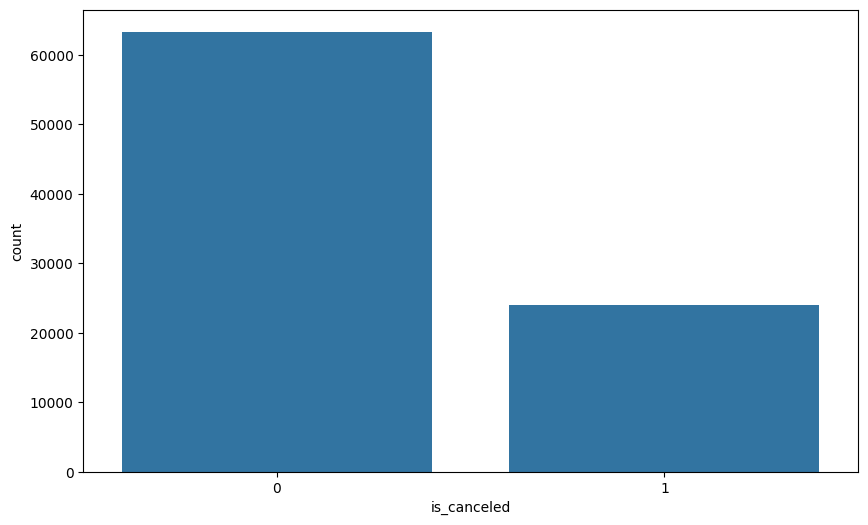

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(x='is_canceled', data=hotel_bookings)
plt.show()

# Feature Engineering

In [33]:
# Feature Selection and Engineering
target = hotel_bookings['is_canceled']

drop_cols = [
	'is_canceled',
	'reservation_status',
	'reservation_status_date',
	'arrival_date_year',
	'arrival_date_month',
	'arrival_date_week_number',
	'arrival_date_day_of_month',
	'country',
	'customer_type',
	'deposit_type',
	'meal',
	'market_segment',
	'distribution_channel'
]

features = hotel_bookings.drop(columns=drop_cols)